In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import spectrogram

sys.path.append(r"../src")
sys.path.append(r"../config")

from loading import load_synchronized_sequence
from dataset_config import get_dataset_window


# ----------------
# Instellingen
# ----------------
phase = "preswitch"
fs = 256

patients = [
    "002", "004", "005", "006", "009",
    "010", "011", "012", "014", "015",
    "016", "017", "018",
]

sync_base = Path(
    r"C:\Users\Kaspe\OneDrive\Documenten\TM2\Code\data\test"
)


# -----------------------------------------------
# Helpers
# -----------------------------------------------
def dynamic_ylim(signal, margin=0.1):
    signal = np.asarray(signal)

    if len(signal) == 0:
        return -1, 1

    y_min = np.min(signal)
    y_max = np.max(signal)
    y_range = y_max - y_min

    if y_range == 0:
        y_range = max(abs(y_min), 1.0)

    return y_min - margin * y_range, y_max + margin * y_range


def load_pes_segment(patient, phase, sync_base):
    sync_path = sync_base / f"SWITCH{patient}_{phase}_sync"

    sequence = load_synchronized_sequence(sync_path)
    pes_signal = sequence.continuous_data["synchronized_pes"]

    time = pes_signal.time
    pes = pes_signal.values

    t_start_rel, t_end_rel = get_dataset_window(patient, phase)

    t_start = time[0] + t_start_rel
    t_end = time[0] + t_end_rel

    mask = (time >= t_start) & (time <= t_end)

    if not mask.any():
        raise ValueError(f"Leeg PES segment voor patient {patient}, phase {phase}")

    return {
        "patient": patient,
        "time": time,
        "pes": pes,
        "time_segment": time[mask],
        "pes_segment": pes[mask],
        "t_start": t_start,
        "t_end": t_end,
        "t_start_rel": t_start_rel,
        "t_end_rel": t_end_rel,
    }


# -----------------------------
# Data inladen
# -----------------------------
datasets = []

for patient in patients:
    try:
        dataset = load_pes_segment(patient, phase, sync_base)
        datasets.append(dataset)
        print(f"OK: SWITCH{patient} - {phase}")

    except Exception as e:
        print(f"FOUT: SWITCH{patient} - {phase} -> {e}")

OK: SWITCH002 - preswitch
OK: SWITCH004 - preswitch
OK: SWITCH005 - preswitch
OK: SWITCH006 - preswitch
OK: SWITCH009 - preswitch
OK: SWITCH010 - preswitch
OK: SWITCH011 - preswitch
OK: SWITCH012 - preswitch
OK: SWITCH014 - preswitch
OK: SWITCH015 - preswitch
OK: SWITCH016 - preswitch
OK: SWITCH017 - preswitch
OK: SWITCH018 - preswitch


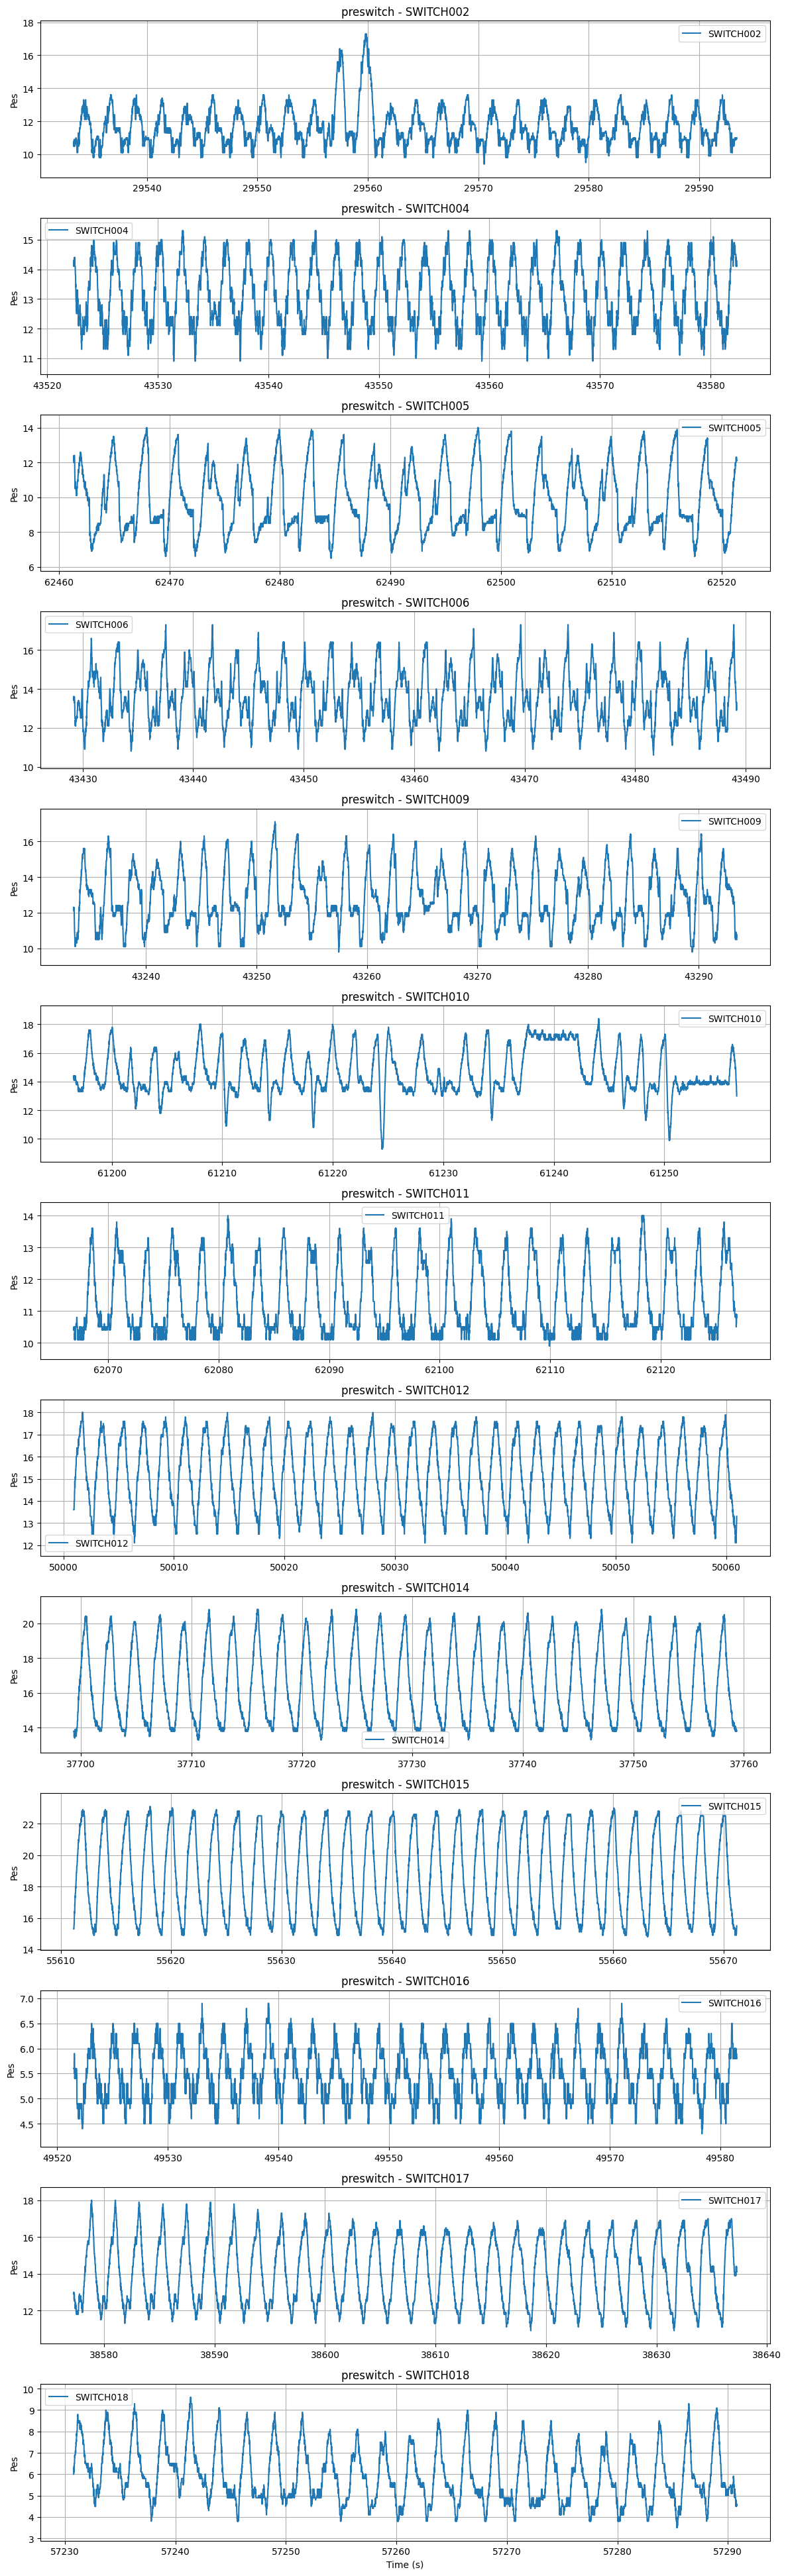

In [2]:
fig, axes = plt.subplots(
    len(datasets),
    1,
    figsize=(12, 3 * len(datasets)),
    sharex=False,
)

if len(datasets) == 1:
    axes = [axes]

for ax, data in zip(axes, datasets):
    t = data["time_segment"]
    p = data["pes_segment"]
    patient = data["patient"]

    ax.plot(t, p, label=f"SWITCH{patient}")
    ax.set_ylabel("Pes")
    ax.set_title(f"{phase} - SWITCH{patient}")
    ax.set_ylim(*dynamic_ylim(p))
    ax.legend()
    ax.grid(True)

axes[-1].set_xlabel("Time (s)")

plt.tight_layout()
plt.show()

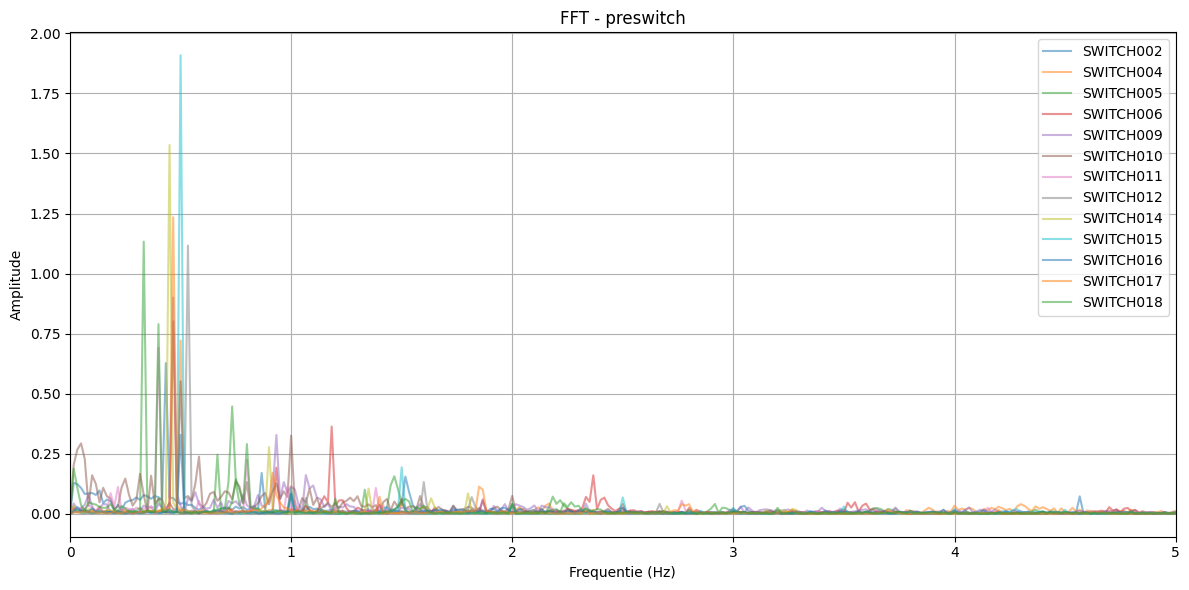

In [3]:
plt.figure(figsize=(12, 6))

for data in datasets:
    p = data["pes_segment"]
    patient = data["patient"]

    N = len(p)
    freqs = np.fft.rfftfreq(N, d=1 / fs)
    fft_vals = np.fft.rfft(p - np.mean(p))

    amp = np.abs(fft_vals) / N

    plt.plot(freqs, amp, label=f"SWITCH{patient}", alpha=0.5)

plt.xlabel("Frequentie (Hz)")
plt.ylabel("Amplitude")
plt.title(f"FFT - {phase}")
plt.xlim(0, 5)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

C:\Users\Kaspe\AppData\Local\Temp\ipykernel_19420\3096568141.py:56: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


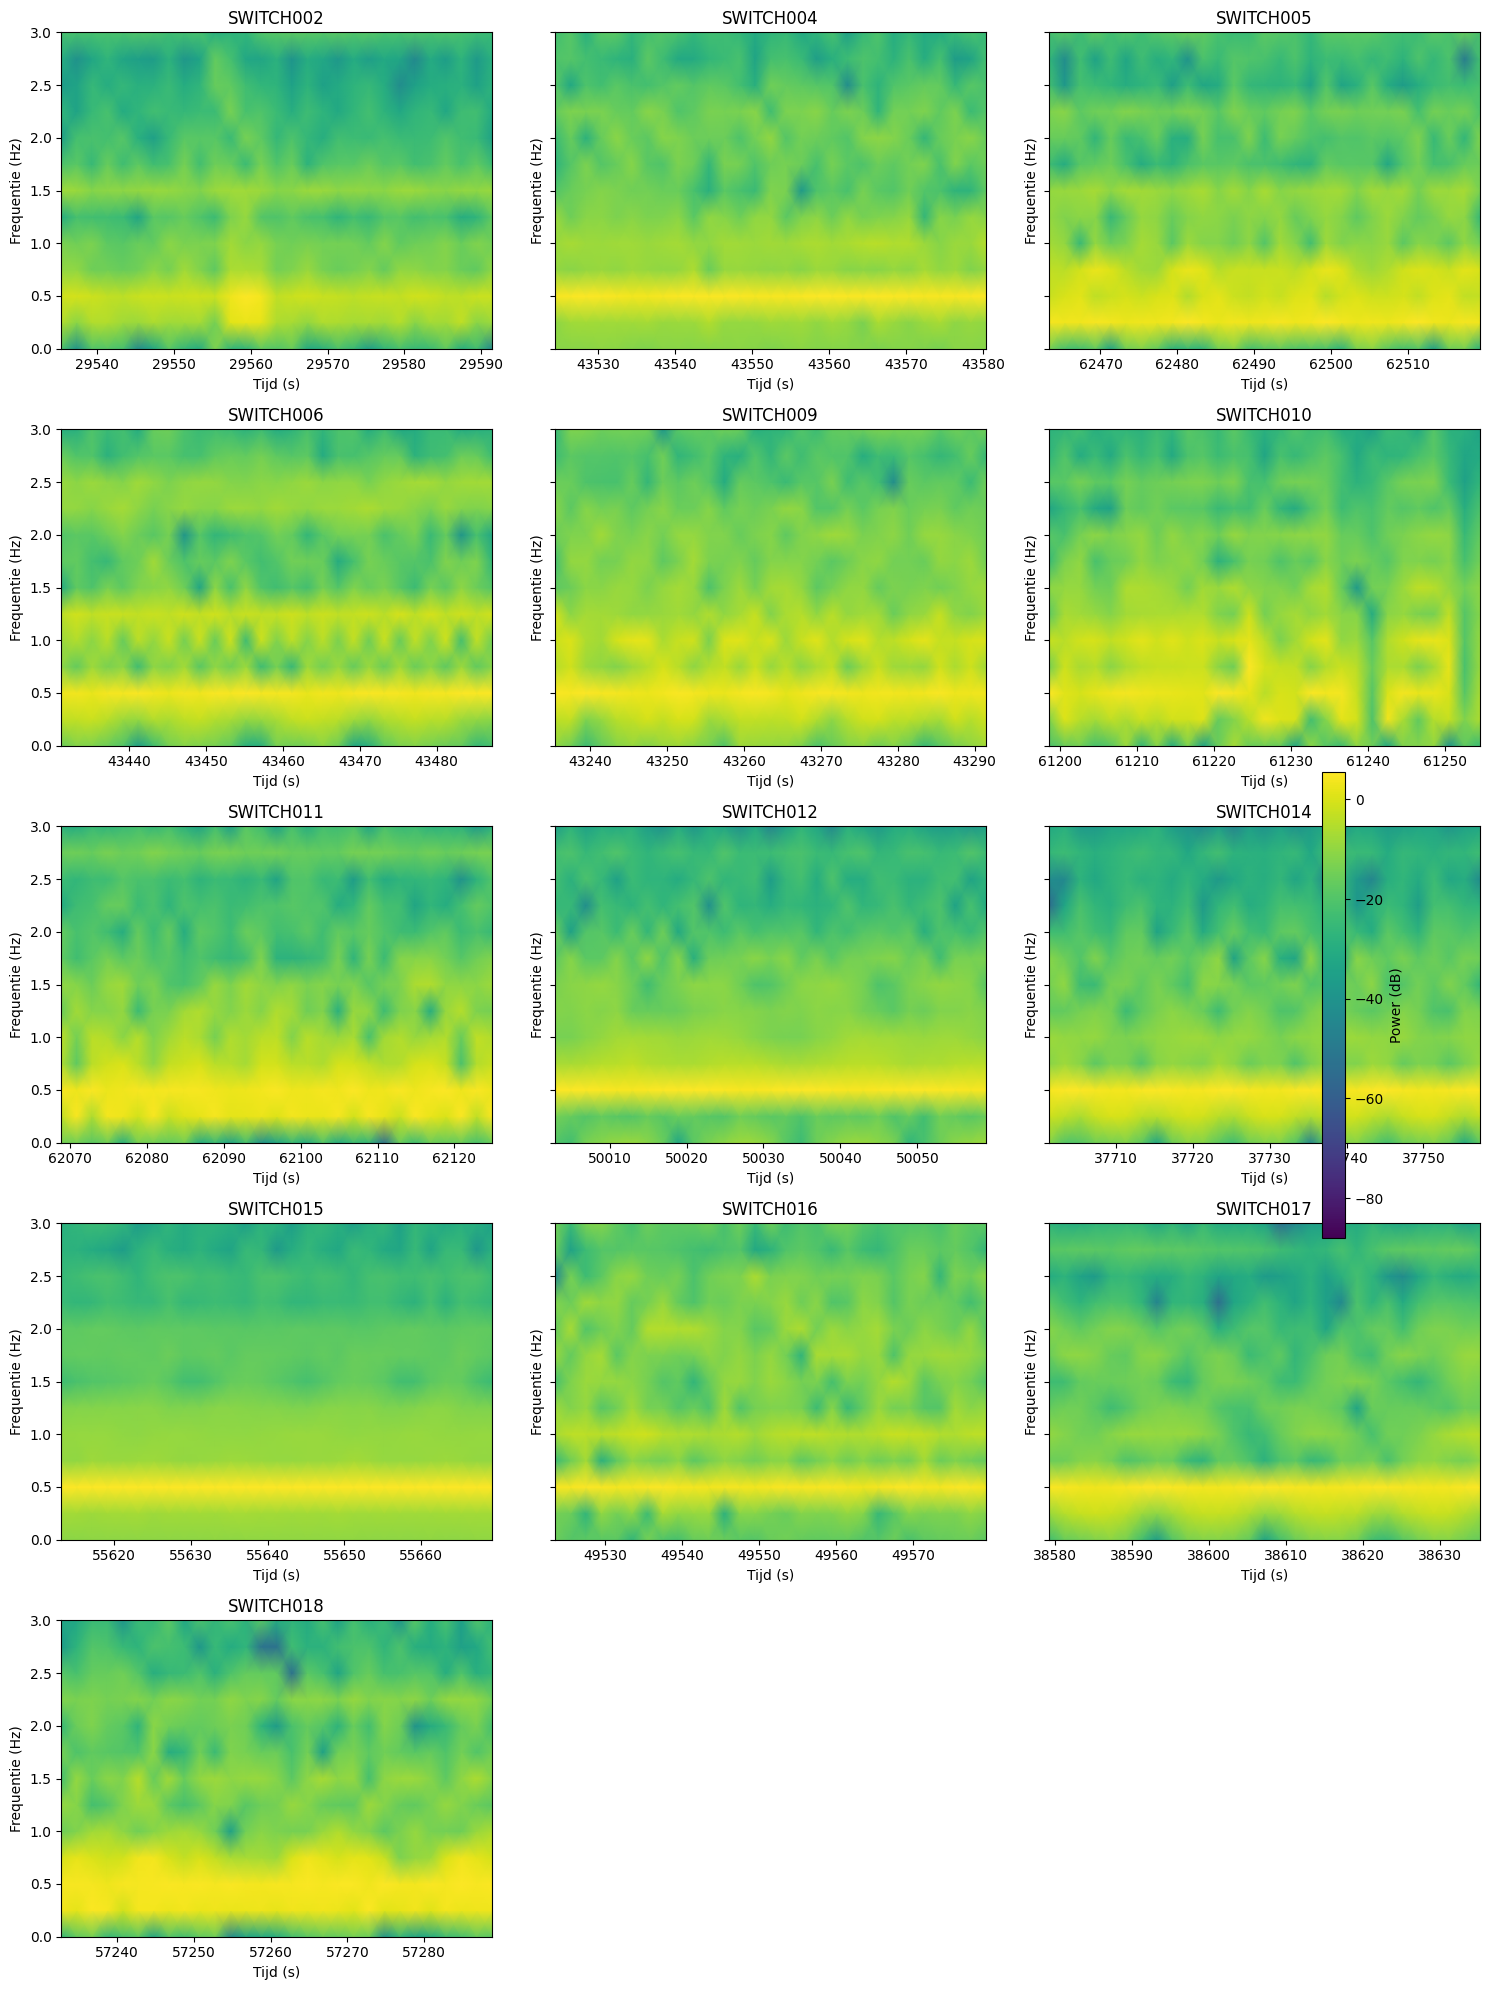

In [4]:
n_patients = len(datasets)
n_cols = 3
n_rows = int(np.ceil(n_patients / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(15, 4 * n_rows),
    sharex=False,
    sharey=True,
)

axes = axes.flatten()

for i, data in enumerate(datasets):
    t = data["time_segment"]
    p = data["pes_segment"]
    patient = data["patient"]

    f, t_spec, Sxx = spectrogram(
        p,
        fs=fs,
        nperseg=1024,
        noverlap=512,
    )

    Sxx_dB = 10 * np.log10(Sxx + 1e-12)

    ax = axes[i]

    pcm = ax.pcolormesh(
        t_spec + t[0],
        f,
        Sxx_dB,
        shading="gouraud",
    )

    ax.set_title(f"SWITCH{patient}")
    ax.set_ylabel("Frequentie (Hz)")
    ax.set_xlabel("Tijd (s)")
    ax.set_ylim(0, 3)
    ax.grid(False)

for ax in axes[len(datasets):]:
    ax.axis("off")

fig.colorbar(
    pcm,
    ax=axes,
    label="Power (dB)",
    orientation="vertical",
    fraction=0.02,
    pad=0.04,
)

plt.tight_layout()
plt.show()